In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.preprocessing import StandardScaler
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_std = StandardScaler().fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.776210,1.828592,-0.293151,0.726273,-0.360668,-0.421860,0.669266,-1.164445,-0.785034,-1.101176,-0.964653,0.646616,-0.296907,-0.179158
1,-0.737256,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,0.105775,-0.964653,-1.098689,-0.763433,-0.587333
2,-0.158251,-0.546869,3.411211,-1.376893,-0.360668,-0.421860,0.669266,-1.164445,1.273829,0.705374,1.036642,-0.581431,0.191169,-0.192863
3,1.354953,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,0.550384,-0.964653,-1.499271,-0.705173,-0.594926
4,0.985240,-0.546869,-0.293151,-1.376893,-0.360668,2.370453,-1.494175,-1.164445,1.273829,1.233028,-0.964653,-1.032545,-0.613919,-0.540373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.024835,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,-0.785034,-1.101176,-0.964653,-0.312822,-0.615257,-0.488161
135,1.105290,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,-0.785034,-1.101176,1.036642,-0.704742,0.522969,-0.099128
136,-0.354794,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,1.273829,0.638406,-0.964653,0.535536,-0.413130,-0.282017
137,0.703351,-0.546869,-0.293151,0.726273,-0.360668,-0.421860,0.669266,0.858778,1.273829,2.049005,1.036642,-0.642817,0.038162,-0.253362


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

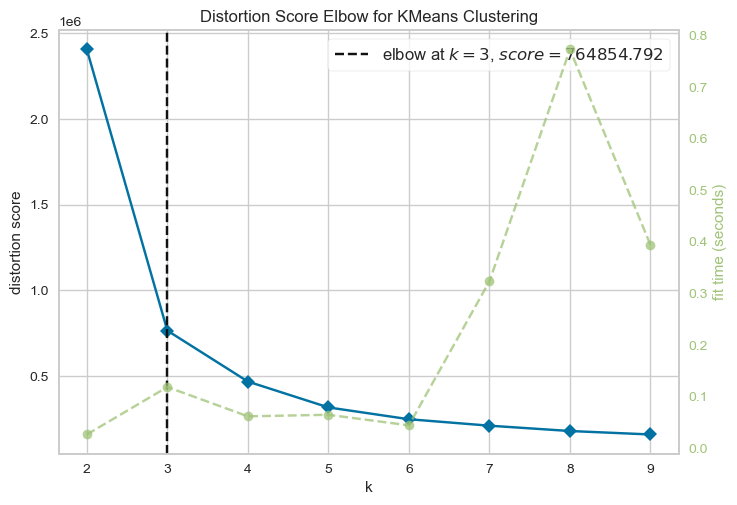

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 3 
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=3)

0
Most correlated column: larynx
Correlation coefficient: 1.007246376811598


1
Most correlated column: histgrade_high
Correlation coefficient: 1.0072463768115956


2
Most correlated column: SUVpeak
Correlation coefficient: 1.007246376811595




In [22]:
selected_features

['larynx', 'histgrade_high', 'SUVpeak']

In [25]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [26]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [27]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [28]:
X_new

,larynx,histgrade_high,SUVpeak
0,0,1,14.473272
1,1,0,5.044678
2,0,1,7.839043
3,1,0,2.880631
4,1,0,5.402006
...,...,...,...
134,0,1,9.290139
135,0,1,7.172883
136,0,1,13.873187
137,0,1,7.507419


In [29]:
X_new_std

,larynx,histgrade_high,SUVpeak
0,0,1,0.646616
1,1,0,-1.098689
2,0,1,-0.581431
3,1,0,-1.499271
4,1,0,-1.032545
...,...,...,...
134,0,1,-0.312822
135,0,1,-0.704742
136,0,1,0.535536
137,0,1,-0.642817


In [30]:
MAASTRO_new

,larynx,histgrade_high,SUVpeak
0,0,1,15.438583
1,0,0,8.829353
2,0,0,13.476123
3,1,1,8.632732
4,0,1,9.783954
...,...,...,...
94,1,0,31.338410
95,1,0,13.041604
96,0,1,8.944517
97,0,1,14.184236


In [31]:
MAASTRO_new_std

,larynx,histgrade_high,SUVpeak
0,0,1,0.825303
1,0,0,-0.398117
2,0,0,0.462036
3,1,1,-0.434513
4,0,1,-0.221413
...,...,...,...
94,1,0,3.768483
95,1,0,0.381603
96,0,1,-0.376799
97,0,1,0.593113


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [32]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:12:44,752] A new study created in memory with name: no-name-76f00c8b-42e9-4be9-88b6-e14f4153cd6d


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:12:45,021] A new study created in memory with name: no-name-54b4f2ed-80d3-444a-ade2-087fd9dd8350


Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.5209125475285171
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:12:45,013] Trial 0 finished with value: 0.5408635436919743 and parameters: {}. Best is trial 0 with value: 0.5408635436919743.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5408635436919743], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 44, 843731), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 45, 13085), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5408635436919743


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24668121365140644
Fold 2 IBS: 0.22228711868574708
Fold 3 IBS: 0.24148553619972718
Fold 4 IBS: 0.27216053833508613
Fold 5 IBS: 0.2288820788356797
[I 2024-04-13 17:12:45,349] Trial 0 finished with value: 0.24229929714152929 and parameters: {}. Best is trial 0 with value: 0.24229929714152929.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24229929714152929], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 45, 107034), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 45, 349215), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24229929714152929


In [33]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [34]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.541
train_ibs:  0.242


#### Test

In [35]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [36]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.578
IBS score: 0.227


In [37]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [38]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [39]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:12:45,590] A new study created in memory with name: no-name-7b76b745-a369-46ba-98e2-1ac59af42a1b


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.4860557768924303


[I 2024-04-13 17:12:45,795] A new study created in memory with name: no-name-d39ef58c-1b57-42b9-a8a0-f169f00b97f7


Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.4531914893617021
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.5150214592274678
[I 2024-04-13 17:12:45,788] Trial 0 finished with value: 0.4868480858868409 and parameters: {}. Best is trial 0 with value: 0.4868480858868409.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.4868480858868409], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 45, 625650), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 45, 787818), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.4868480858868409


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709967802544
Fold 2 IBS: 0.23203988268661027
Fold 3 IBS: 0.2289818688433014
Fold 4 IBS: 0.24197477920308627
Fold 5 IBS: 0.2293955945101016
[I 2024-04-13 17:12:46,095] Trial 0 finished with value: 0.23592784498422503 and parameters: {}. Best is trial 0 with value: 0.23592784498422503.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784498422503], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 45, 845357), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 46, 95382), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784498422503


In [40]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [41]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.487
train_ibs:  0.236


#### Test

In [42]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [43]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.571


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [44]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [45]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:12:46,363] A new study created in memory with name: no-name-debb669d-d865-4529-ac1e-9386040f4287


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.49800796812749004

[I 2024-04-13 17:12:46,623] A new study created in memory with name: no-name-f423eff5-e20d-42ab-b3a0-81f7b5b20cd3



Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.5150214592274678
[I 2024-04-13 17:12:46,613] Trial 0 finished with value: 0.4979934792345729 and parameters: {}. Best is trial 0 with value: 0.4979934792345729.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.4979934792345729], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 46, 404802), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 46, 613382), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.4979934792345729


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24750962773778648
Fold 2 IBS: 0.22844660889450327
Fold 3 IBS: 0.2413026654057202
Fold 4 IBS: 0.25786096168587114
Fold 5 IBS: 0.23090041063603584
[I 2024-04-13 17:12:46,896] Trial 0 finished with value: 0.24120405487198343 and parameters: {}. Best is trial 0 with value: 0.24120405487198343.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24120405487198343], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 46, 661136), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 46, 896187), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24120405487198343


In [46]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [47]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.498
train_ibs:  0.241


#### Test

In [48]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [49]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.55


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.227


In [50]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [51]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:12:47,148] A new study created in memory with name: no-name-1edeb879-e470-467b-be55-a9f00416d2c8


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5059760956175299
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.5150214592274678
[I 2024-04-13 17:12:47,410] Trial 0 finished with value: 0.49958710473258083 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.49958710473258083.
Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.4531914893617021
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.51931330472103
[I 2024-04-13 17:12:47,515] Trial 1 finished with value: 0.4956018695251137 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.49958710473258083.
Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.4531914893617021
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.5236051502145923
[I 2024-04-13 17:12:47,669] Trial 2 finished with value: 0.49805386412183417 and parameters: {'l1_ratio': 0.2269287684188

Fold 5 C-index: 0.5150214592274678
[I 2024-04-13 17:12:51,320] Trial 24 finished with value: 0.49879029198357683 and parameters: {'l1_ratio': 0.7602371709740536}. Best is trial 0 with value: 0.49958710473258083.
Fold 1 C-index: 0.5099601593625498
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.4531914893617021
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.51931330472103
[I 2024-04-13 17:12:51,424] Trial 25 finished with value: 0.49400824402710575 and parameters: {'l1_ratio': 0.5833004187842314}. Best is trial 0 with value: 0.49958710473258083.
Fold 1 C-index: 0.5059760956175299
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.5150214592274678
[I 2024-04-13 17:12:51,584] Trial 26 finished with value: 0.49958710473258083 and parameters: {'l1_ratio': 0.683379796474269}. Best is trial 0 with value: 0.49958710473258083.
Fold 1 C-index: 0.4900398406374502
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index

Fold 3 C-index: 0.4531914893617021
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.51931330472103
[I 2024-04-13 17:12:54,871] Trial 49 finished with value: 0.49400824402710575 and parameters: {'l1_ratio': 0.5968274215260415}. Best is trial 0 with value: 0.49958710473258083.
Fold 1 C-index: 0.5139442231075697
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.4531914893617021
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.51931330472103
[I 2024-04-13 17:12:54,984] Trial 50 finished with value: 0.4948050567761097 and parameters: {'l1_ratio': 0.556147470734502}. Best is trial 0 with value: 0.49958710473258083.
Fold 1 C-index: 0.5059760956175299
Fold 2 C-index: 0.5465116279069767
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.5150214592274678
[I 2024-04-13 17:12:55,197] Trial 51 finished with value: 0.49958710473258083 and parameters: {'l1_ratio': 0.6935484815938594}. Best is trial 0 with value: 0.49958710473258083.
Fold 1 C-index: 

...

Fold 1 IBS: 0.24733136704163616
Fold 2 IBS: 0.2287046465078337
Fold 3 IBS: 0.2412328710627479
Fold 4 IBS: 0.25661504401586627
Fold 5 IBS: 0.23084027075898877
[I 2024-04-13 17:13:02,793] Trial 0 finished with value: 0.24094483987741455 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24094483987741455.
Fold 1 IBS: 0.24704398917619175
Fold 2 IBS: 0.22957430772027412
Fold 3 IBS: 0.23144576448292992
Fold 4 IBS: 0.25261514190292583
Fold 5 IBS: 0.23060587354052978
[I 2024-04-13 17:13:02,944] Trial 1 finished with value: 0.2382570153645703 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.2382570153645703.
Fold 1 IBS: 0.24701014423087583
Fold 2 IBS: 0.2298349704770511
Fold 3 IBS: 0.23094170936135563
Fold 4 IBS: 0.25145382093633534
Fold 5 IBS: 0.2305234203895971
[I 2024-04-13 17:13:03,124] Trial 2 finished with value: 0.237952813079043 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.237952813079043.


Fold 1 IBS: 0.24701210538517454
Fold 2 IBS: 0.23098421985265308
Fold 3 IBS: 0.2295900330090982
Fold 4 IBS: 0.24644884756040317
Fold 5 IBS: 0.23005870796592393
[I 2024-04-13 17:13:07,114] Trial 25 finished with value: 0.23681878275465057 and parameters: {'l1_ratio': 0.07330522822697523}. Best is trial 13 with value: 0.23599378931488588.
Fold 1 IBS: 0.24699928590288747
Fold 2 IBS: 0.22996020502813966
Fold 3 IBS: 0.23073448604705146
Fold 4 IBS: 0.2509000658410897
Fold 5 IBS: 0.2304813312693853
[I 2024-04-13 17:13:07,281] Trial 26 finished with value: 0.23781507481771072 and parameters: {'l1_ratio': 0.20309774849254153}. Best is trial 13 with value: 0.23599378931488588.
Fold 1 IBS: 0.24703388076569638
Fold 2 IBS: 0.2311777033808615
Fold 3 IBS: 0.22944813492211313
Fold 4 IBS: 0.24562049791093576
Fold 5 IBS: 0.22995864274542252
[I 2024-04-13 17:13:07,450] Trial 27 finished with value: 0.23664777194500583 and parameters: {'l1_ratio': 0.056847137315710346}. Best is trial 13 with value: 0.23599

Fold 5 IBS: 0.2307402813120727
[I 2024-04-13 17:13:11,550] Trial 49 finished with value: 0.2388948670533643 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 46 with value: 0.235929676633509.
Fold 1 IBS: 0.24699509198734074
Fold 2 IBS: 0.23076245140561674
Fold 3 IBS: 0.22977541519117892
Fold 4 IBS: 0.24740287015560156
Fold 5 IBS: 0.23016428169158287
[I 2024-04-13 17:13:11,714] Trial 50 finished with value: 0.23702002208626416 and parameters: {'l1_ratio': 0.09451319327765746}. Best is trial 46 with value: 0.235929676633509.
Fold 1 IBS: 0.24720511502524975
Fold 2 IBS: 0.2319310194519403
Fold 3 IBS: 0.2290287028399233
Fold 4 IBS: 0.24243057789719827
Fold 5 IBS: 0.22947935990998874
[I 2024-04-13 17:13:11,893] Trial 51 finished with value: 0.23601495502486008 and parameters: {'l1_ratio': 0.006012844952470507}. Best is trial 46 with value: 0.235929676633509.
Fold 1 IBS: 0.24722591978448633
Fold 2 IBS: 0.23198701414128667
Fold 3 IBS: 0.22900427296789339
Fold 4 IBS: 0.24219603024

Fold 5 IBS: 0.2294235120316734
[I 2024-04-13 17:13:18,385] Trial 74 finished with value: 0.2359562505254485 and parameters: {'l1_ratio': 0.001939745630995339}. Best is trial 63 with value: 0.23592945401096221.
Fold 1 IBS: 0.24707504456121296
Fold 2 IBS: 0.23143801952110057
Fold 3 IBS: 0.22928181853557555
Fold 4 IBS: 0.2445118073540913
Fold 5 IBS: 0.2298106422966198
[I 2024-04-13 17:13:18,564] Trial 75 finished with value: 0.23642346645372 and parameters: {'l1_ratio': 0.03717982365573151}. Best is trial 63 with value: 0.23592945401096221.
Fold 1 IBS: 0.2470143170367734
Fold 2 IBS: 0.2310069797174419
Fold 3 IBS: 0.22957244203437152
Fold 4 IBS: 0.24635121593032794
Fold 5 IBS: 0.23004734039212504
[I 2024-04-13 17:13:18,768] Trial 76 finished with value: 0.236798459022208 and parameters: {'l1_ratio': 0.0712774675720134}. Best is trial 63 with value: 0.23592945401096221.
Fold 1 IBS: 0.24698623958953966
Fold 2 IBS: 0.23055376253886697
Fold 3 IBS: 0.22997605270786742
Fold 4 IBS: 0.248305278978

Fold 5 IBS: 0.23027766475307562
[I 2024-04-13 17:13:23,243] Trial 99 finished with value: 0.23726563951086402 and parameters: {'l1_ratio': 0.12345871196024548}. Best is trial 63 with value: 0.23592945401096221.


* Best trial for IBS: 
 FrozenTrial(number=63, state=TrialState.COMPLETE, values=[0.23592945401096221], datetime_start=datetime.datetime(2024, 4, 13, 17, 13, 14, 964111), datetime_complete=datetime.datetime(2024, 4, 13, 17, 13, 15, 280380), params={'l1_ratio': 0.00010944776235348343}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=63, value=None)


* Best Score for IBS: 
 0.23592945401096221


In [52]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [53]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [54]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [55]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.552


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.00010944776235348343)

test_ibs:  0.229


In [56]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [57]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:13:23,490] A new study created in memory with name: no-name-de895976-2bc7-478f-b511-190d3f95f8e7


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4243027888446215
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.5361702127659574
Fold 4 C-index: 0.5152091254752852
Fold 5 C-index: 0.41630901287553645
[I 2024-04-13 17:13:28,318] Trial 0 finished with value: 0.5117315613256135 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5117315613256135.
Fold 1 C-index: 0.5199203187250996
Fold 2 C-index: 0.6143410852713178
Fold 3 C-index: 0.44468085106382976
Fold 4 C-index: 0.5418250950570342
Fold 5 C-index: 0.4291845493562232
[I 2024-04-13 17:13:31,233] Trial 1 finished with value: 0.509990379894701 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717,

Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.5836909871244635
[I 2024-04-13 17:13:58,395] Trial 15 finished with value: 0.5522278662551858 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 8, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 135, 'oob_score': True, 'max_samples': 0.9915444131569726, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.4533275126681895, 'warm_start': True}. Best is trial 14 with value: 0.5596211494594253.
Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.5678294573643411
Fold 3 C-index: 0.6829787234042554
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:13:59,293] Trial 16 finished with value: 0.5567189152538367 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 8, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 154, 'oob_score': True, 'max_samples': 0.963196029824611, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.43699859292892884, 'warm_start': True}. Best is 

Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.6647286821705426
Fold 3 C-index: 0.6936170212765957
Fold 4 C-index: 0.5817490494296578
Fold 5 C-index: 0.5042918454935622
[I 2024-04-13 17:14:12,775] Trial 30 finished with value: 0.5797139730605259 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 3, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 45, 'oob_score': True, 'max_samples': 0.7644243628829415, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.23092078565296814, 'warm_start': True}. Best is trial 30 with value: 0.5797139730605259.
Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.6763565891472868
Fold 3 C-index: 0.7297872340425532
Fold 4 C-index: 0.6045627376425855
Fold 5 C-index: 0.48068669527896996
[I 2024-04-13 17:14:13,181] Trial 31 finished with value: 0.5891153046087332 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 2, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 51, 'oob_score': True, 'max_samples': 0.8013062909511224, 

...

Fold 1 IBS: 0.246386460438482
Fold 2 IBS: 0.23218899742898796
Fold 3 IBS: 0.22946758410602397
Fold 4 IBS: 0.24118772219117468
Fold 5 IBS: 0.2303071920630508
[I 2024-04-13 17:17:02,342] Trial 32 finished with value: 0.2359075912455439 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 8, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 175, 'oob_score': True, 'max_samples': 0.20444340416617043, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.19558060234973634}. Best is trial 27 with value: 0.23583547084615547.
Fold 1 IBS: 0.24684478929600995
Fold 2 IBS: 0.2322329224950302
Fold 3 IBS: 0.23005427140610996
Fold 4 IBS: 0.2412308304074783
Fold 5 IBS: 0.2301271605653773
[I 2024-04-13 17:17:05,947] Trial 33 finished with value: 0.23609799483400112 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 235, 'oob_score': True, 'max_samples': 0.23980153995474307, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22978676956550373
[I 2024-04-13 17:17:43,740] Trial 47 finished with value: 0.23575678560731528 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 160, 'oob_score': True, 'max_samples': 0.13434415907111946, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10612603041708193}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24757897353687755
Fold 2 IBS: 0.2320725752850252
Fold 3 IBS: 0.2299544780683508
Fold 4 IBS: 0.24154478404388094
Fold 5 IBS: 0.23016145399352744
[I 2024-04-13 17:17:45,394] Trial 48 finished with value: 0.2362624529855324 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 86, 'oob_score': True, 'max_samples': 0.12964207163685623, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10203918387448863}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24671151151924972
Fold 2 IBS: 0.2321

Fold 1 IBS: 0.24631928839139375
Fold 2 IBS: 0.23211332325251055
Fold 3 IBS: 0.22987340393724426
Fold 4 IBS: 0.24110794902474542
Fold 5 IBS: 0.2296571564179856
[I 2024-04-13 17:18:20,355] Trial 63 finished with value: 0.2358142242047759 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 150, 'oob_score': True, 'max_samples': 0.10056089265752739, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.026471209866795242}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24648722835656947
Fold 2 IBS: 0.23206092276817514
Fold 3 IBS: 0.22928811947466984
Fold 4 IBS: 0.24128731957110403
Fold 5 IBS: 0.22992351169818162
[I 2024-04-13 17:18:22,133] Trial 64 finished with value: 0.23580942037374003 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 104, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fractio

Fold 5 IBS: 0.24563106345286742
[I 2024-04-13 17:18:58,691] Trial 78 finished with value: 0.24242260869132098 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 171, 'oob_score': True, 'max_samples': 0.9147835512625551, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13257772422273512}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24630596960013934
Fold 2 IBS: 0.23202892604980208
Fold 3 IBS: 0.23058361904315297
Fold 4 IBS: 0.24129573617042252
Fold 5 IBS: 0.2301768553877985
[I 2024-04-13 17:18:59,483] Trial 79 finished with value: 0.2360782212502631 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 12, 'n_estimators': 37, 'oob_score': True, 'max_samples': 0.2189744006895358, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17152888523323856}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24642825384745612
Fold 2 IBS: 0.232

Fold 1 IBS: 0.24603980142682666
Fold 2 IBS: 0.23212293756683253
Fold 3 IBS: 0.22980177266109972
Fold 4 IBS: 0.24117019375096946
Fold 5 IBS: 0.23000323031974987
[I 2024-04-13 17:19:46,034] Trial 94 finished with value: 0.23582758714509566 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 186, 'oob_score': True, 'max_samples': 0.15211446012016716, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1336981908011637}. Best is trial 84 with value: 0.23572114547332967.
Fold 1 IBS: 0.24609144860992238
Fold 2 IBS: 0.23210462726436726
Fold 3 IBS: 0.23027168009436597
Fold 4 IBS: 0.24100241364516664
Fold 5 IBS: 0.2300638162943246
[I 2024-04-13 17:19:52,936] Trial 95 finished with value: 0.23590679718162938 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 489, 'oob_score': True, 'max_samples': 0.12627955102410032, 'max_features': 'auto', 'min_weight_fraction

In [58]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [59]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.61
train_ibs:  0.236


#### Test

In [60]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [61]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=17, max_features='log2', max_leaf_nodes=20,
                     max_samples=0.9342656737316277, min_samples_leaf=10,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.16855081501009073,
                     n_estimators=323, random_state=123, warm_start=True)

test_cindex:  0.548


RandomSurvivalForest(max_depth=3, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.1369774849788948, min_samples_leaf=2,
                     min_samples_split=20,
                     min_weight_fraction_leaf=0.07082006896114468,
                     n_estimators=186, oob_score=True, random_state=123)

test_ibs:  0.23


In [62]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [63]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:20:08,023] A new study created in memory with name: no-name-25cba01d-87e5-4d57-b561-1cb26adc39f5


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.5446808510638298
Fold 4 C-index: 0.6482889733840305
Fold 5 C-index: 0.5901287553648069
[I 2024-04-13 17:20:09,312] Trial 0 finished with value: 0.5822983965888653 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.5822983965888653.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:20:12,400] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.49203187250996017
Fold 2 C-index: 0.5872093023255814
Fold 3 C-index: 0.5638297872340425
Fold 4 C-index: 0.6197718631178707
Fold 5 C-index: 0.5600858369098712
[I 2024-04-13 17:20:47,994] Trial 16 finished with value: 0.5645857324194652 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 14, 'min_samples_leaf': 8, 'max_depth': 20, 'n_estimators': 104, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8706063821261315, 'min_weight_fraction_leaf': 0.1756935604393659}. Best is trial 3 with value: 0.5968751920426791.
Fold 1 C-index: 0.5298804780876494
Fold 2 C-index: 0.6182170542635659
Fold 3 C-index: 0.5872340425531914
Fold 4 C-index: 0.6577946768060836
Fold 5 C-index: 0.5815450643776824
[I 2024-04-13 17:20:49,204] Trial 17 finished with value: 0.5949342632176345 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 9, 'n_estimators': 277, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.5239043824701195
Fold 2 C-index: 0.5988372093023255
Fold 3 C-index: 0.597872340425532
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.5815450643776824
[I 2024-04-13 17:21:13,925] Trial 31 finished with value: 0.59046982212882 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 6, 'max_depth': 12, 'n_estimators': 366, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.7433920039501473, 'min_weight_fraction_leaf': 0.08559430884722963}. Best is trial 27 with value: 0.5970806815180201.
Fold 1 C-index: 0.5199203187250996
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.5936170212765958
Fold 4 C-index: 0.6634980988593155
Fold 5 C-index: 0.5901287553648069
[I 2024-04-13 17:21:15,476] Trial 32 finished with value: 0.5955258621009776 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 11, 'n_estimators': 371, 'oob_score': False, 'warm_start': True, 'max_features

...

Fold 1 IBS: 0.24716656487794766
Fold 2 IBS: 0.22944996366921439
Fold 3 IBS: 0.22785628182522066
Fold 4 IBS: 0.24008547318278747
Fold 5 IBS: 0.23104704005293214
[I 2024-04-13 17:25:13,614] Trial 30 finished with value: 0.23512106472162048 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 18, 'min_samples_leaf': 9, 'max_depth': 8, 'n_estimators': 161, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.4875906623897354, 'min_weight_fraction_leaf': 0.11806271853024425}. Best is trial 18 with value: 0.23460568419512723.
Fold 1 IBS: 0.24643595978477353
Fold 2 IBS: 0.22751910471661527
Fold 3 IBS: 0.22964617566608425
Fold 4 IBS: 0.2394118210829008
Fold 5 IBS: 0.2305622958297099
[I 2024-04-13 17:25:20,037] Trial 31 finished with value: 0.23471507141601675 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 12, 'max_depth': 10, 'n_estimators': 287, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.9285

Fold 1 IBS: 0.24651717169682352
Fold 2 IBS: 0.22773115601050925
Fold 3 IBS: 0.22858383858368303
Fold 4 IBS: 0.23989837674602948
Fold 5 IBS: 0.23050586270612128
[I 2024-04-13 17:27:21,552] Trial 45 finished with value: 0.23464728114863326 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 3, 'min_samples_leaf': 13, 'max_depth': 20, 'n_estimators': 485, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9991674227108049, 'min_weight_fraction_leaf': 0.1611660164779409}. Best is trial 32 with value: 0.23458245891121762.
Fold 1 IBS: 0.24682130080218492
Fold 2 IBS: 0.22780781474902514
Fold 3 IBS: 0.22798861095820355
Fold 4 IBS: 0.23989847067026818
Fold 5 IBS: 0.23108923721312435
[I 2024-04-13 17:27:34,438] Trial 46 finished with value: 0.2347210868785612 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 3, 'min_samples_leaf': 14, 'max_depth': 20, 'n_estimators': 490, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 

Fold 1 IBS: 0.24604855813596882
Fold 2 IBS: 0.22744904318804432
Fold 3 IBS: 0.23085951298936158
Fold 4 IBS: 0.23914232528004006
Fold 5 IBS: 0.22937608474370072
[I 2024-04-13 17:29:52,449] Trial 60 finished with value: 0.23457510486742308 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 3, 'min_samples_leaf': 11, 'max_depth': 12, 'n_estimators': 304, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.8585109351335336, 'min_weight_fraction_leaf': 0.008809099467680716}. Best is trial 59 with value: 0.23451436246608232.
Fold 1 IBS: 0.2460516590349808
Fold 2 IBS: 0.2274479522853039
Fold 3 IBS: 0.23096275123332674
Fold 4 IBS: 0.2390910930391661
Fold 5 IBS: 0.2294591082299214
[I 2024-04-13 17:29:58,543] Trial 61 finished with value: 0.23460251276453978 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 3, 'min_samples_leaf': 11, 'max_depth': 12, 'n_estimators': 308, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0

Fold 1 IBS: 0.24527770840398058
Fold 2 IBS: 0.22714024934492544
Fold 3 IBS: 0.23731165835065213
Fold 4 IBS: 0.23982563573425805
Fold 5 IBS: 0.22790529493355433
[I 2024-04-13 17:31:19,018] Trial 75 finished with value: 0.23549210935347414 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 14, 'n_estimators': 302, 'oob_score': True, 'warm_start': True, 'max_features': 1, 'max_samples': 0.9304234004571232, 'min_weight_fraction_leaf': 0.08247900999864893}. Best is trial 59 with value: 0.23451436246608232.
Fold 1 IBS: 0.2470724971865244
Fold 2 IBS: 0.2276428744894745
Fold 3 IBS: 0.22870786426665074
Fold 4 IBS: 0.23971930723523902
Fold 5 IBS: 0.23114351004306657
[I 2024-04-13 17:31:29,617] Trial 76 finished with value: 0.23485721064419107 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 12, 'max_depth': 10, 'n_estimators': 344, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.7964

Fold 1 IBS: 0.2460239599745305
Fold 2 IBS: 0.22750064954593213
Fold 3 IBS: 0.23008608658372467
Fold 4 IBS: 0.2397012672348658
Fold 5 IBS: 0.2296536614545877
[I 2024-04-13 17:33:30,512] Trial 90 finished with value: 0.23459312495872814 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 5, 'min_samples_leaf': 12, 'max_depth': 10, 'n_estimators': 387, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9680078050399054, 'min_weight_fraction_leaf': 0.12706673043201602}. Best is trial 79 with value: 0.23436774323799897.
Fold 1 IBS: 0.2460454347271542
Fold 2 IBS: 0.2274777429333106
Fold 3 IBS: 0.23011077459003096
Fold 4 IBS: 0.2397003719210852
Fold 5 IBS: 0.22966715475189944
[I 2024-04-13 17:33:41,980] Trial 91 finished with value: 0.23460029578469607 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 5, 'min_samples_leaf': 12, 'max_depth': 10, 'n_estimators': 385, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.

In [64]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [65]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.634
train_ibs:  0.234


#### Test

In [66]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [67]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=13, max_features=None, max_leaf_nodes=16,
                   max_samples=0.5388971054964918, min_samples_leaf=2,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.008524624133669462,
                   n_estimators=225, random_state=123, warm_start=True)

C-index score: 0.531


ExtraSurvivalTrees(max_depth=14, max_features=None, max_leaf_nodes=2,
                   max_samples=0.7391795997163304, min_samples_leaf=13,
                   min_samples_split=11,
                   min_weight_fraction_leaf=0.059623288633005186,
                   n_estimators=194, oob_score=True, random_state=123,
                   warm_start=True)

IBS: 0.232


In [68]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [69]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:35:10,399] A new study created in memory with name: no-name-660f79d7-25bc-41b4-9377-0a1ce6288a29


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:36:01,023] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:36:35,092] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:45:21,972] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:46:34,843] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:55:35,203] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:55:54,768] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.46231

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:23:03,075] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:23:12,273] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:28:51,971] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 19:29:31,434] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:34:06,093] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:34:48,050] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:39:20,964] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:40:10,643] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:13:43,563] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:13:45,429] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [70]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [71]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [72]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [73]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [74]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [75]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 20:18:02,846] A new study created in memory with name: no-name-09a474e8-42f4-4764-8f21-c5f6eed45557


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.549800796812749
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.43829787234042555
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.51931330472103
[I 2024-04-13 20:18:05,074] Trial 0 finished with value: 0.5059743922989368 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5059743922989368.
Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.4531914893617021
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.5236051502145923
[I 2024-04-13 20:18:22,304] Trial 1 finished with value: 0.5106082975509085 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.5106082975509085.
Fold 1 C-index: 0.5577689243027888
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.4531914893617021
Fold 

Fold 5 C-index: 0.5493562231759657
[I 2024-04-13 20:21:14,588] Trial 18 finished with value: 0.5245861801943826 and parameters: {'subsample': 0.34810348568738264, 'dropout_rate': 0.3438278728179395, 'n_estimators': 430, 'learning_rate': 0.08279335722009089}. Best is trial 11 with value: 0.5334044068552908.
Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.44106463878326996
Fold 5 C-index: 0.5450643776824035
[I 2024-04-13 20:21:28,648] Trial 19 finished with value: 0.5261182493426821 and parameters: {'subsample': 0.19816662555708264, 'dropout_rate': 0.6170255353098466, 'n_estimators': 400, 'learning_rate': 0.08909215792368923}. Best is trial 11 with value: 0.5334044068552908.
Fold 1 C-index: 0.5617529880478087
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.41702127659574467
Fold 4 C-index: 0.4372623574144487
Fold 5 C-index: 0.5493562231759657
[I 2024-04-13 20:21:35,501] Trial 20 finished with value: 0.509357

Fold 1 C-index: 0.5657370517928287
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.4372623574144487
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 20:24:55,460] Trial 37 finished with value: 0.5254809057683347 and parameters: {'subsample': 0.28791112493130167, 'dropout_rate': 0.1628159321460021, 'n_estimators': 337, 'learning_rate': 0.07616870784115887}. Best is trial 22 with value: 0.5335030139312265.
Fold 1 C-index: 0.5617529880478087
Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.44866920152091255
Fold 5 C-index: 0.5493562231759657
[I 2024-04-13 20:25:01,536] Trial 38 finished with value: 0.5292078679357096 and parameters: {'subsample': 0.1504722419513361, 'dropout_rate': 0.398882401389722, 'n_estimators': 239, 'learning_rate': 0.08480908032505553}. Best is trial 22 with value: 0.5335030139312265.
Fold 1 C-index: 0.5577689243027888
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.417021276595744

...

Fold 2 IBS: 0.2361853117992355
Fold 3 IBS: 0.311338113140207
Fold 4 IBS: 0.35586380117695493
Fold 5 IBS: 0.23693090644217896
[I 2024-04-13 20:42:16,210] Trial 19 finished with value: 0.2766359960263874 and parameters: {'subsample': 0.650899739648275, 'dropout_rate': 0.9954484919483726, 'n_estimators': 400, 'learning_rate': 0.011730584939170362}. Best is trial 15 with value: 0.23603121318451792.
Fold 1 IBS: 0.24593579244915587
Fold 2 IBS: 0.2330302320749739
Fold 3 IBS: 0.2522645345839797
Fold 4 IBS: 0.2777021249100158
Fold 5 IBS: 0.2329608420177305
[I 2024-04-13 20:42:17,506] Trial 20 finished with value: 0.24837870520717115 and parameters: {'subsample': 0.9010126869682862, 'dropout_rate': 0.6173032374045795, 'n_estimators': 67, 'learning_rate': 0.0257290746252228}. Best is trial 15 with value: 0.23603121318451792.
Fold 1 IBS: 0.24723713233036015
Fold 2 IBS: 0.23203784606135297
Fold 3 IBS: 0.22914790430996748
Fold 4 IBS: 0.24226573328512094
Fold 5 IBS: 0.22942931935346514
[I 2024-04-13 

Fold 3 IBS: 0.4371442786354374
Fold 4 IBS: 0.4493519967269197
Fold 5 IBS: 0.24712313658619248
[I 2024-04-13 20:42:46,236] Trial 38 finished with value: 0.32780544617117247 and parameters: {'subsample': 0.5872963751371887, 'dropout_rate': 0.13272164755980653, 'n_estimators': 158, 'learning_rate': 0.0802388198308747}. Best is trial 22 with value: 0.2359433149331458.
Fold 1 IBS: 0.24633638060744104
Fold 2 IBS: 0.2329621629191557
Fold 3 IBS: 0.2516387572781116
Fold 4 IBS: 0.27743207391362557
Fold 5 IBS: 0.23302073757677516
[I 2024-04-13 20:42:53,687] Trial 39 finished with value: 0.2482780224590218 and parameters: {'subsample': 0.9436047786916928, 'dropout_rate': 0.6881141432789704, 'n_estimators': 309, 'learning_rate': 0.005489826361343792}. Best is trial 22 with value: 0.2359433149331458.
Fold 1 IBS: 0.24538342071678024
Fold 2 IBS: 0.23245378984017334
Fold 3 IBS: 0.2541755993959579
Fold 4 IBS: 0.2828704289862007
Fold 5 IBS: 0.23277941705027802
[I 2024-04-13 20:42:55,110] Trial 40 finishe

Fold 4 IBS: 0.24422139043308994
Fold 5 IBS: 0.22871809091851292
[I 2024-04-13 20:43:22,482] Trial 57 finished with value: 0.23654244256907275 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.8162611417796318, 'n_estimators': 21, 'learning_rate': 0.008868594848667265}. Best is trial 49 with value: 0.2359370170441622.
Fold 1 IBS: 0.2440951173139722
Fold 2 IBS: 0.23302559075914847
Fold 3 IBS: 0.2791996180994119
Fold 4 IBS: 0.3133980061424947
Fold 5 IBS: 0.2299460544100928
[I 2024-04-13 20:43:25,655] Trial 58 finished with value: 0.25993287734502407 and parameters: {'subsample': 0.39051296535426056, 'dropout_rate': 0.870118816142991, 'n_estimators': 180, 'learning_rate': 0.017718465773746365}. Best is trial 49 with value: 0.2359370170441622.
Fold 1 IBS: 0.24646171038126466
Fold 2 IBS: 0.2319664515700108
Fold 3 IBS: 0.23489524356701508
Fold 4 IBS: 0.2512406332955611
Fold 5 IBS: 0.22992759600848395
[I 2024-04-13 20:43:26,538] Trial 59 finished with value: 0.23889832696446

Fold 5 IBS: 0.23134290284321093
[I 2024-04-13 20:44:06,093] Trial 76 finished with value: 0.26996831348040173 and parameters: {'subsample': 0.3765100403339643, 'dropout_rate': 0.6733476040864279, 'n_estimators': 302, 'learning_rate': 0.014837152633505877}. Best is trial 49 with value: 0.2359370170441622.
Fold 1 IBS: 0.24463448525465112
Fold 2 IBS: 0.23125627261682322
Fold 3 IBS: 0.2634122301181217
Fold 4 IBS: 0.29368719399161586
Fold 5 IBS: 0.22998793137104648
[I 2024-04-13 20:44:15,942] Trial 77 finished with value: 0.25259562267045166 and parameters: {'subsample': 0.24882711549849235, 'dropout_rate': 0.659742465572864, 'n_estimators': 337, 'learning_rate': 0.008044525525950186}. Best is trial 49 with value: 0.2359370170441622.
Fold 1 IBS: 0.2464331568312806
Fold 2 IBS: 0.2319407826061989
Fold 3 IBS: 0.23761664483617276
Fold 4 IBS: 0.2548664256321934
Fold 5 IBS: 0.22986206298340325
[I 2024-04-13 20:44:17,395] Trial 78 finished with value: 0.24014381457784978 and parameters: {'subsampl

Fold 5 IBS: 0.2296762509824875
[I 2024-04-13 20:44:30,771] Trial 95 finished with value: 0.23714574138305564 and parameters: {'subsample': 0.6678005402872682, 'dropout_rate': 0.8453292958886656, 'n_estimators': 41, 'learning_rate': 0.006091454222608763}. Best is trial 49 with value: 0.2359370170441622.
Fold 1 IBS: 0.2467868849453235
Fold 2 IBS: 0.232031013501591
Fold 3 IBS: 0.23249856017468548
Fold 4 IBS: 0.24689870043214845
Fold 5 IBS: 0.2288262838719608
[I 2024-04-13 20:44:31,504] Trial 96 finished with value: 0.23740828858514185 and parameters: {'subsample': 0.2738824604193379, 'dropout_rate': 0.537157724728395, 'n_estimators': 32, 'learning_rate': 0.011952484399759211}. Best is trial 49 with value: 0.2359370170441622.
Fold 1 IBS: 0.24666482404539658
Fold 2 IBS: 0.2317930389140008
Fold 3 IBS: 0.23421755243666179
Fold 4 IBS: 0.2504771488604046
Fold 5 IBS: 0.22953670119738045
[I 2024-04-13 20:44:46,412] Trial 97 finished with value: 0.23853785309076886 and parameters: {'subsample': 0.

In [76]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [77]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.539
train_ibs:  0.236


#### Test

In [78]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [79]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.15666174270679292,
                                              learning_rate=0.09771488720305649,
                                              n_estimators=329,
                                              random_state=123,
                                              subsample=0.1617409550330779)

C-index score: 0.576


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8878567210334715,
                                              learning_rate=0.0016388078764098802,
                                              n_estimators=1, random_state=123,
                                              subsample=0.9935080009387302)

IBS: 0.229


In [80]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [81]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
ExtraSurvivalTrees,0.634,1.0
Randomsurvivalforest,0.610,2.0
CoxPH,0.541,3.0
ComponentwiseGradientBoosting,0.539,4.0
CoxElastic,0.500,5.5
GradientBoosting,0.500,5.5
CoxLasso,0.498,7.0
CoxRidge,0.487,8.0


In [82]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.234,1.0
CoxRidge,0.236,4.0
CoxElastic,0.236,4.0
Randomsurvivalforest,0.236,4.0
GradientBoosting,0.236,4.0
ComponentwiseGradientBoosting,0.236,4.0
CoxLasso,0.241,7.0
CoxPH,0.242,8.0


In [83]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.578,1.0
ComponentwiseGradientBoosting,0.576,2.0
CoxRidge,0.571,3.0
CoxElastic,0.552,4.0
CoxLasso,0.550,5.0
Randomsurvivalforest,0.548,6.0
ExtraSurvivalTrees,0.531,7.0
GradientBoosting,0.500,8.0


In [84]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxPH,0.227,1.5
CoxLasso,0.227,1.5
CoxRidge,0.229,4.5
CoxElastic,0.229,4.5
GradientBoosting,0.229,4.5
ComponentwiseGradientBoosting,0.229,4.5
Randomsurvivalforest,0.230,7.0
ExtraSurvivalTrees,0.232,8.0


In [85]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/standard/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_standard_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [86]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-13
